# POGEMA dataset EDA

Compact overview of the final model targets and input features. Target distributions use every recorded instance–seed–neighbourhood row; feature distributions use the seed-0, neighbourhood-4 row for each instance.

In [82]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from mapf_anytime.features import LACAM_FEATURES, STATIC_FEATURES

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
DATASET = ROOT / "datasets/pogema_final.csv"
data = pd.read_csv(DATASET)
print(f"{len(data):,} rows × {data.shape[1]} columns; {data.instance_id.nunique():,} instances")

94,221 rows × 48 columns; 4,959 instances


## Generation-feature selection bias: retained 4,959 vs excluded 5,041

The retained cohort is read from `pogema_final.csv`; its complete 10,000-instance generation run is identified from the local manifests. The comparison uses the three independent requested generation variables. Standardized mean differences quantify location shifts without depending on sample size; KS distances quantify any distributional shift.

In [83]:
import json
import numpy as np
from scipy.stats import ks_2samp

POGEMA = ROOT / "datasets/pogema"
GENERATION_FEATURES = (
    "requested_map_size",
    "requested_obstacle_density",
    "requested_agent_density",
)
GENERATION_LABELS = {feature: feature.removeprefix("requested_") for feature in GENERATION_FEATURES}
SELECTED_IDS = set(data.instance_id.unique())
selected_manifest = json.loads(
    (POGEMA / "instances" / f"{next(iter(SELECTED_IDS))}.json").read_text()
)
SELECTED_RUN_ID = selected_manifest["generation_run_id"]

In [84]:
def generation_features(path):
    manifest = json.loads(path.read_text())
    if manifest.get("generation_run_id") != SELECTED_RUN_ID:
        return None
    return {
        "instance_id": manifest["name"],
        "generation_run_id": manifest["generation_run_id"],
        **{feature: manifest[feature] for feature in GENERATION_FEATURES},
    }

records = (
    generation_features(path) for path in sorted((POGEMA / "instances").glob("*.json"))
)
generation_cohort = pd.DataFrame(record for record in records if record is not None)
selected_generation = generation_cohort[generation_cohort["instance_id"].isin(SELECTED_IDS)]
excluded_generation = generation_cohort[~generation_cohort["instance_id"].isin(SELECTED_IDS)]
assert len(generation_cohort) == 10_000
assert len(selected_generation) == 4_959
assert len(excluded_generation) == 5_041
display(pd.Series({"retained": len(selected_generation), "excluded": len(excluded_generation)}, name="instances"))
display(selected_generation.head())

retained    4959
excluded    5041
Name: instances, dtype: int64

,instance_id,generation_run_id,requested_map_size,requested_obstacle_density,requested_agent_density
0,pogema-balanced-000000-s327-d0p060-a25142-seed...,20260627_211805,327,0.060,0.250138
1,pogema-balanced-000001-s203-d0p226-a2321-seed1...,20260627_211805,203,0.226,0.072930
3,pogema-balanced-000003-s237-d0p236-a532-seed18...,20260627_211805,237,0.236,0.012450
6,pogema-balanced-000006-s385-d0p258-a4549-seed1...,20260627_211805,385,0.258,0.041584
7,pogema-balanced-000007-s251-d0p174-a13128-seed...,20260627_211805,251,0.174,0.252372


### Retained-cohort generation distributions

,count,mean,std,min,25%,50%,75%,max
requested_map_size,4959.0,140.6523,94.6971,8.0,64.0000,127.0000,195.0000,493.0000
requested_obstacle_density,4959.0,0.1568,0.0869,0.0,0.0820,0.1600,0.2340,0.3000
requested_agent_density,4959.0,0.1383,0.0879,0.0,0.0593,0.1342,0.2132,0.2999


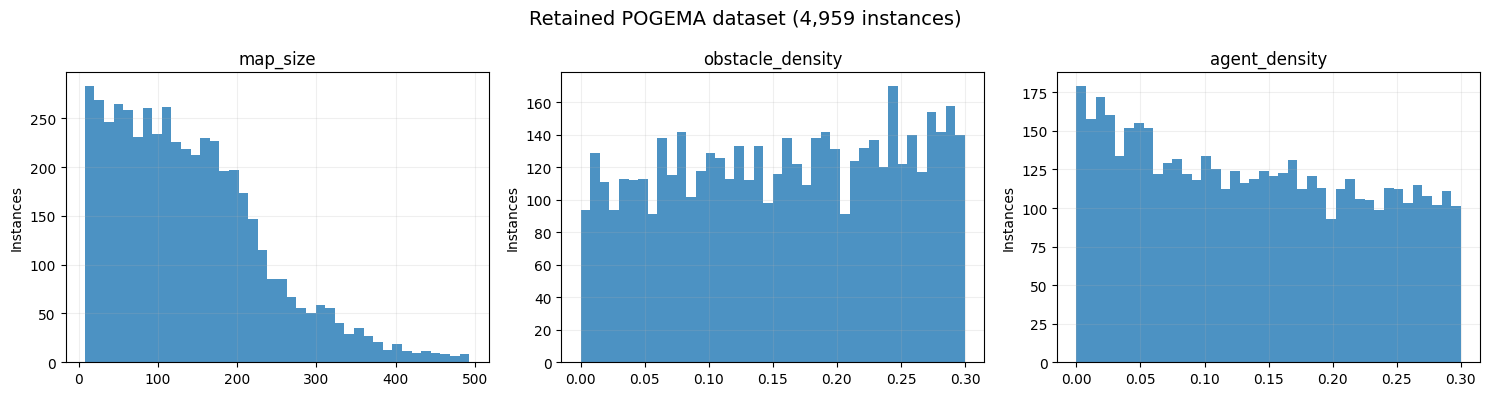

In [85]:
display(selected_generation[list(GENERATION_FEATURES)].describe().T.round(4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4), squeeze=False)
for axis, feature in zip(axes.flat, GENERATION_FEATURES):
    axis.hist(selected_generation[feature].dropna(), bins=40, color="tab:blue", alpha=0.8)
    axis.set_title(GENERATION_LABELS[feature])
    axis.set_ylabel("Instances")
    axis.grid(alpha=0.2)
fig.suptitle("Retained POGEMA dataset (4,959 instances)", fontsize=14)
plt.tight_layout()
plt.show()

In [86]:
def standardized_mean_difference(left, right):
    pooled_sd = np.sqrt((left.var(ddof=1) + right.var(ddof=1)) / 2)
    return (left.mean() - right.mean()) / pooled_sd if pooled_sd else 0.0

rows = []
for feature in GENERATION_FEATURES:
    retained = selected_generation[feature].dropna()
    excluded = excluded_generation[feature].dropna()
    ks = ks_2samp(retained, excluded)
    rows.append({
        "feature": feature,
        "retained median": retained.median(),
        "excluded median": excluded.median(),
        "retained mean": retained.mean(),
        "excluded mean": excluded.mean(),
        "standardized mean difference": standardized_mean_difference(retained, excluded),
        "KS distance": ks.statistic,
        "KS p-value": ks.pvalue,
    })
selection_effects = pd.DataFrame(rows).set_index("feature")
selection_effects["absolute SMD"] = selection_effects["standardized mean difference"].abs()
display(selection_effects.sort_values("absolute SMD", ascending=False).round(4))

,retained median,excluded median,retained mean,excluded mean,standardized mean difference,KS distance,KS p-value,absolute SMD
feature,,,,,,,,
requested_map_size,127.0000,366.0000,140.6523,360.3882,-2.4272,0.7668,0.0,2.4272
requested_agent_density,0.1342,0.1616,0.1383,0.1600,-0.2520,0.1089,0.0,0.2520
requested_obstacle_density,0.1600,0.1440,0.1568,0.1454,0.1314,0.0593,0.0,0.1314
